In [18]:
import sys
import os

current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from a_star import A_star

from utils.graph_helpers import (
    create_chromo_graph,
    get_peak_distance_heuristic,
    print_path
)

In [21]:
# Imports
import pickle
import networkx as nx
import numpy as np
import math
from scipy import interpolate
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
# Constant
EPS_JREL = 1e-12

# Function to compute the spectral overlap integral from photochemCAD data
def compute_relative_J(lambda_em_nm, int_em, lambda_abs_nm, absorbance, grid_res=1.0):
    """
    Compute relative spectral overlap J_rel = integral F_D(lambda) * A_A(lambda) * lambda^4 dlambda
    Inputs: 
      - lambda_em_nm, int_em: donor emission wavelengths (nm) and intensities (arbitary units)
      - lambda_abs_nm, absorbance: acceptor wavelengths (nm) and absorbance A(lambda) (arbitrary units)
      - grid_res: Resolution of the wavelength grid for numerical integration, nominally 1 nm spacing over overlap.
    Returns:
      - J_rel (numeric, arbitrary units)
    """
    lam_min = max(min(lambda_em_nm), min(lambda_abs_nm))
    lam_max = min(max(lambda_em_nm), max(lambda_abs_nm))
    grid_nm = np.arange(lam_min, lam_max + grid_res, grid_res)

    f_em = interpolate.interp1d(lambda_em_nm, int_em, bounds_error=False, fill_value=0.0)
    f_abs = interpolate.interp1d(lambda_abs_nm, absorbance, bounds_error=False, fill_value=0.0)
    I_D = f_em(grid_nm)
    A_A = f_abs(grid_nm)

    delta = np.mean(np.diff(grid_nm))  # nm
    area = np.sum(I_D) * delta
    if area <= 0:
        raise ValueError("Donor emission has zero area after interpolation.")
    F_D = I_D / area

    # Use lambda in nm, include nm^4 factor - units are arbitrary so J_rel units also arbitrary
    J_rel = np.sum(F_D * A_A * (grid_nm**4)) * delta

    return J_rel

def generate_weight(C):
    def Jrel_to_weight(Jrel):
        e = 1 / (1 + (C/Jrel))
        return e
    return Jrel_to_weight

# Built the fret graph
def build_fret_graph(molecules, ems_abs):
    """
    Builds a directed graph where edge i to j represents fret efficiency of donor i exciting acceptor j
    Weight = -log(E(i to j))
    """

    # Directed graph
    G = nx.DiGraph()

    # Add nodes
    for m in molecules:
        G.add_node(m)

    Jrels = []

    # Add weighted edges
    for donor in molecules:
        for acceptor in molecules:
            if donor == acceptor:
                continue  # bc we don't want self FRET

            lam_em, inten_em = ems_abs[donor]['emission']['wavelength'], ems_abs[donor]['emission']['intensity']
            lam_abs, absorb = ems_abs[acceptor]['absorption']['wavelength'], ems_abs[acceptor]['absorption']['intensity']

            # Calculate J rel
            try:
                J_rel = compute_relative_J(
                    lam_em, inten_em,
                    lam_abs, absorb,
                    grid_res=1.0
                )
                Jrels.append(J_rel)
            except Exception as e:
                continue

    # For the arbitrary constant in E calculation
    J_rel_mean = np.nanmean(Jrels)

    # Specific function using the current constant
    Jrel_to_weight = generate_weight(J_rel_mean)

    # Add weighted edges
    for donor in molecules:
        for acceptor in molecules:
            if donor == acceptor:
                continue  # bc we don't want self FRET

            lam_em, inten_em = ems_abs[donor]['emission']['wavelength'], ems_abs[donor]['emission']['intensity']
            lam_abs, absorb = ems_abs[acceptor]['absorption']['wavelength'], ems_abs[acceptor]['absorption']['intensity']

            # Calculate J_rel
            try:
                J_rel = compute_relative_J(
                    lam_em, inten_em,
                    lam_abs, absorb,
                    grid_res=1.0
                )
            except Exception:
                continue

            if J_rel <= EPS_JREL or np.isnan(J_rel):
                print('no edge')
                continue

            # Convert to edge weight
            w = -math.log(Jrel_to_weight(J_rel))
            print(J_rel, w)

            # Add edge
            G.add_edge(donor, acceptor, weight=w, J_rel=J_rel)

    return G


In [39]:
# Load in spectral data for natural chlorophylls in Et20 solvent
et20_spectra = pickle.load(open('./et20_spectra.pkl', 'rb'))
et20_spectra_clean = {k.split('_')[0]: v for k,v in et20_spectra.items()}
et20_molecules = list(et20_spectra_clean.keys())

In [56]:
et20_spectra['CHL070_Chl b2']['absorption'].keys()

dict_keys(['wavelength', 'intensity'])

In [64]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(et20_spectra['CHL070_Chl b2']['absorption']['intensity'])
peaks[-1]
et20_spectra['CHL070_Chl b2']['absorption']['wavelength'][peaks[-1]]

645.0

In [62]:
peaks[-1]

np.int64(184)

In [63]:
et20_spectra['CHL070_Chl b2']['absorption']['wavelength'][peaks[-1]]

645.0

In [41]:
et20_graph = build_fret_graph(et20_molecules, et20_spectra_clean)

1754754907.0055676 2.555407141095408
11492646321.657314 1.0343830164606473
18673752307.16014 0.7495404538199352
994388176.9774041 3.0891329788524713
17714606867.4449 0.7776969150417754
16743542367.426754 0.8085647431355256
36501314721.81208 0.45168041397148323
55256942231.93328 0.32001960389334416
53125315597.30645 0.33094837045002923
45024707454.44319 0.38039771709141906
52254280625.59186 0.33563404057674223
25757064516.102287 0.5928375956302053
18212795936.784164 0.7628007780051238
1090507172.8504953 3.0012549048971153
16228081253.953297 0.8260244035601969
21906952808.127216 0.668503646204537
14517662523.887724 0.890160964063976
1200046316.8065314 2.9105199375118964
12135275699.36684 0.9996542038598695
6025639578.795559 1.4948400946002172
48432153852.367905 0.3578851230159029
21320617324.88329 0.6818219277165671
21970645009.540684 0.6670893266092586
53487649004.8277 0.32903787709774857
18299291561.294495 0.7602752172612376
37721888839.53235 0.4398507448288501
10587139883.449179 1.088

/home/alex/miniconda3/envs/MSSE_Python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/alex/miniconda3/envs/MSSE_Python/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


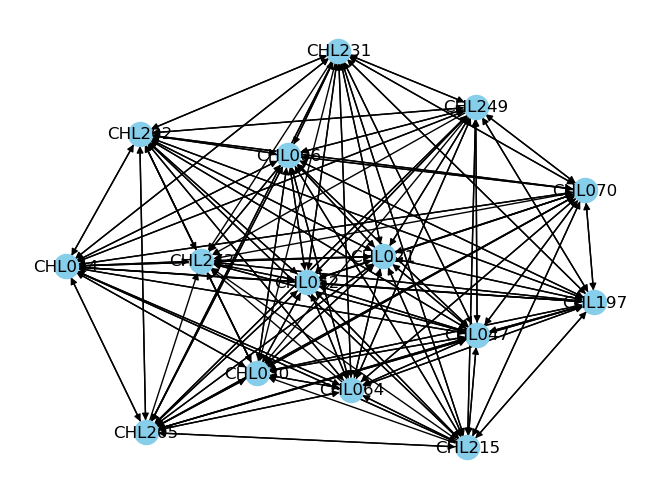

In [42]:
# Plot the networkx graph
fig = plt.figure()
nx.draw(et20_graph, with_labels=True, node_color='skyblue')
fig.savefig('./et20_as_graph.png')

{'CHL070': Text(0.20002707960891955, -0.5173486207836013, 'CHL070'),
 'CHL215': Text(0.8187517550172011, 0.7962137793986738, 'CHL215'),
 'CHL205': Text(0.7690958862980111, -0.47414827169274576, 'CHL205'),
 'CHL014': Text(-0.8026639891927053, -0.5332405016993383, 'CHL014'),
 'CHL249': Text(0.23396256637234375, 1.12, 'CHL249'),
 'CHL273': Text(-0.31556442562342335, 1.0056073119272744, 'CHL273'),
 'CHL047': Text(-0.8188008449517296, 0.44131260135216815, 'CHL047'),
 'CHL021': Text(-0.04362005457097522, 0.40437477069547206, 'CHL021'),
 'CHL064': Text(-0.208703304765301, -0.07206884563272678, 'CHL064'),
 'CHL006': Text(-0.5457353522353485, -0.018434074022445762, 'CHL006'),
 'CHL030': Text(0.1531650081690872, 0.21710477746916945, 'CHL030'),
 'CHL197': Text(-0.30943379908578494, -0.4768794040741907, 'CHL197'),
 'CHL052': Text(0.28894297905418465, 0.5114318356251131, 'CHL052'),
 'CHL202': Text(-0.21560692376905843, -0.8717091337856473, 'CHL202'),
 'CHL231': Text(0.796183419674579, 0.26778377522

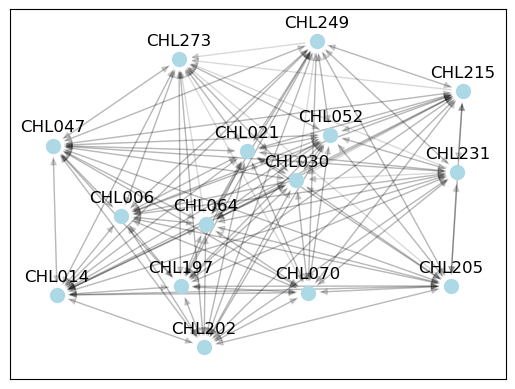

In [51]:
G = et20_graph
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=100)
nx.draw_networkx_edges(G, pos, alpha=0.15)

pos_labels = {node: (x, y+0.12) for node, (x,y) in pos.items()}

nx.draw_networkx_labels(G, pos_labels)

In [14]:
def get_heuristic(g):
    def heuristic(node1, node2):
        return g[node1][node2]['weight']
    return heuristic

In [20]:
et20_spectra

{'CHL070_Chl b2': {'absorption': {'wavelength': [375.38,
    376.57,
    377.61,
    378.93,
    380.07,
    381.36,
    382.64,
    383.55,
    384.73,
    386.04,
    387.33,
    388.37,
    389.59,
    391.04,
    392.76,
    394.34,
    395.86,
    397.25,
    398.73,
    400.15,
    401.87,
    403.49,
    405.54,
    407.87,
    409.86,
    411.62,
    413.91,
    415.7,
    416.95,
    418.16,
    419.24,
    420.62,
    421.7,
    423.56,
    425.92,
    427.57,
    428.69,
    429.87,
    431.45,
    432.8,
    434.22,
    435.77,
    437.15,
    438.5,
    439.65,
    440.63,
    441.64,
    442.59,
    443.5,
    444.31,
    445.52,
    446.87,
    448.29,
    449.6,
    451.69,
    453.08,
    455.47,
    457.22,
    458.32,
    458.81,
    459.45,
    460.01,
    460.51,
    461.01,
    461.61,
    462.21,
    463.0,
    463.91,
    464.48,
    464.88,
    465.32,
    466.03,
    467.01,
    467.79,
    468.63,
    470.05,
    470.86,
    472.02,
    473.02,
    474.26,
  

In [ ]:
heuristic_function = get_peak_distance_heuristic(solvent, chromo_df)

In [17]:
source = 'CHL030_Ch f'
target = 'CHL006_Chl a'
chlf_chla_path = A_star(et20_graph, source, target, get_heuristic)

TypeError: get_heuristic() takes 1 positional argument but 2 were given